# Projeto de Ciência de Dados - Bitcoin Prices
**Autor:** Kauan da Costa Barros  
**Dataset:** Preços Históricos e Projeções de Bitcoin (2010 - 2026)

---
## 1ª Etapa 
## 1. Introdução e Objetivo
Este notebook apresenta o processo de limpeza e tratamento de dados de uma série temporal de preços do Bitcoin. O objetivo é preparar os dados para tarefas subsequentes de **Regressão** (predição de preço) e **Classificação** (categoria de preço).

### 2. Importação de Bibliotecas e Carga dos Dados
Nesta etapa, carregamos o `pandas` para manipulação de DataFrames e o `numpy` para operações matemáticas vetorizadas.

In [57]:
import pandas as pd
import numpy as np

try:
    df = pd.read_csv('bitcoin.csv')
    print("Dataset carregado com sucesso!")
except FileNotFoundError:
    print("Arquivo não encontrado. Verifique o caminho.")

Dataset carregado com sucesso!


### 3. Algoritmo de Limpeza e Ordenação Cronológica
O processo de limpeza segue as seguintes regras de negócio:
1. **Padronização Temporal**: Conversão para o formato `datetime`.
2. **Ordenação**: Organização cronológica (do mais antigo ao mais recente).
3. **Unicidade**: Remoção de possíveis duplicatas por data.
4. **Integridade Lógica**: Garantir que a máxima (`High`) não seja inferior aos outros preços do dia usando **NumPy**.
5. **Continuidade**: Preenchimento de lacunas via interpolação linear.

In [58]:

df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values(by='Date').reset_index(drop=True)

df = df.drop_duplicates(subset=['Date'], keep='first')

df['High'] = np.maximum(df['High'], df[['Open', 'Low', 'Close']].max(axis=1))
df['Low'] = np.minimum(df['Low'], df[['Open', 'High', 'Close']].min(axis=1))


cols_num = ['Open', 'High', 'Low', 'Close', 'Volume']
df[cols_num] = df[cols_num].interpolate(method='linear')

print("Processamento de limpeza e ordenação concluído.")

Processamento de limpeza e ordenação concluído.


### 4. Verificação Final do Dataset
Abaixo, verificamos se a série está estritamente crescente no tempo e se não restaram valores nulos

In [59]:

esta_ordenado = df['Date'].is_monotonic_increasing
total_nulos = df.isnull().sum().sum()

print(f"A série está ordenada? {esta_ordenado}")
print(f"Total de valores nulos: {total_nulos}")

df.head()

A série está ordenada? True
Total de valores nulos: 0


,Date,Open,High,Low,Close,Volume,PriceCategory
0,2010-01-01,0.3,0.303428,0.295510,0.3,715.8,Low
1,2010-01-02,0.3,0.304377,0.299459,0.3,2028.3,Low
2,2010-01-03,0.3,0.303736,0.295858,0.3,273.0,Low
3,2010-01-04,0.3,0.303406,0.298489,0.3,1452.0,Low
4,2010-01-05,0.3,0.302715,0.296330,0.3,1002.6,Low


### 5. Exportação dos Dados Tratados
Após concluir a limpeza, ordenação e verificação de integridade, exportamos o DataFrame resultante para um novo arquivo CSV.

In [60]:

df.to_csv('bitcoin_limpo_ordenado.csv', index=False)

print("Arquivo salvo com sucesso no diretório do Jupyter!")

Arquivo salvo com sucesso no diretório do Jupyter!


# Atividade 2 - Redução de Dimensionalidade (PCA) e Correlação

Nesta fase do projeto, exploramos a relação entre as variáveis e aplicamos técnicas para reduzir a complexidade do dataset, mantendo a maior parte da informação original.


## 2.1 Matriz de Correlação de Pearson
Para entender como cada variável influencia o preço e a categoria final, transformamos a `PriceCategory` em dados numéricos e geramos o mapa de calor (Heatmap).

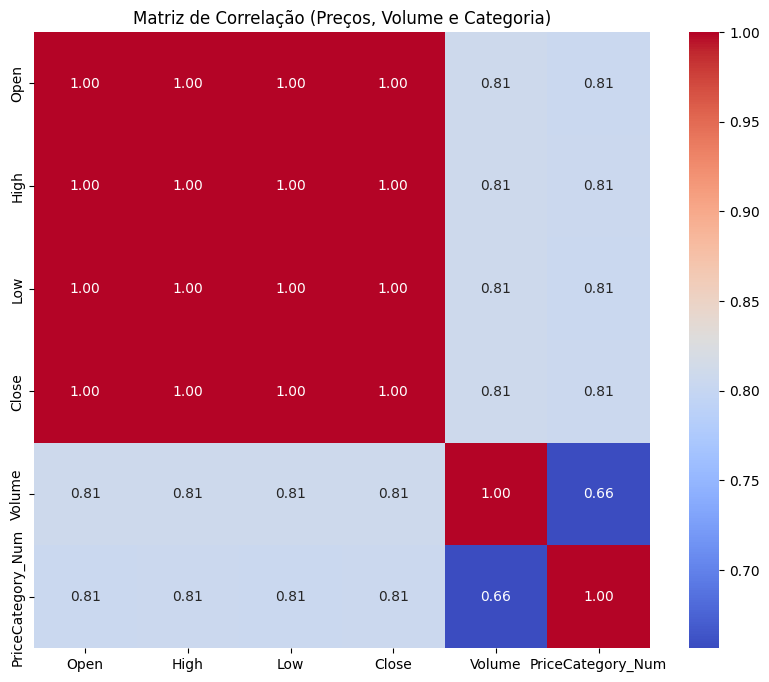

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

mapeamento = {'Low': 0, 'Medium': 1, 'High': 2}
df['PriceCategory_Num'] = df['PriceCategory'].map(mapeamento)


colunas_analise = ['Open', 'High', 'Low', 'Close', 'Volume', 'PriceCategory_Num']
matriz_corr = df[colunas_analise].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_corr, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    square=True
)

plt.title('Matriz de Correlação (Preços, Volume e Categoria)')
plt.show()

## 2.2 Normalização dos Dados (StandardScaler)
Antes de aplicar o PCA, é essencial normalizar os dados para que todas as variáveis contribuam igualmente na análise.  
Utilizamos o **StandardScaler** do scikit-learn, que transforma cada feature para ter **média 0** e **desvio padrão 1** (normalização Z-score).

In [62]:
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('bitcoin_limpo_ordenado.csv')


colunas_numericas = ['Open', 'High', 'Low', 'Close', 'Volume']
X = df[colunas_numericas]


scaler = StandardScaler()
X_normalizado = scaler.fit_transform(X)


df_normalizado = pd.DataFrame(X_normalizado, columns=colunas_numericas)

print('Estatísticas ANTES da normalização:')
print(X.describe().round(2))
print('\nEstatísticas DEPOIS da normalização:')
print(df_normalizado.describe().round(2))

df.head()

Estatísticas ANTES da normalização:
           Open      High       Low     Close        Volume
count   5883.00   5883.00   5883.00   5883.00  5.883000e+03
mean   21725.05  21973.72  21487.58  21736.78  1.087915e+08
std    30114.98  30445.26  29793.03  30119.95  1.851098e+08
min        0.30      0.30      0.29      0.30  3.030000e+01
25%      430.57    431.21    422.13    430.57  1.271205e+06
50%     7193.60   7207.98   7057.97   7193.60  1.756809e+07
75%    42265.19  42370.14  41483.58  42265.19  1.302297e+08
max    93429.20  95281.01  93326.45  93429.20  9.325168e+08

Estatísticas DEPOIS da normalização:
          Open     High      Low    Close   Volume
count  5883.00  5883.00  5883.00  5883.00  5883.00
mean      0.00    -0.00     0.00     0.00    -0.00
std       1.00     1.00     1.00     1.00     1.00
min      -0.72    -0.72    -0.72    -0.72    -0.59
25%      -0.71    -0.71    -0.71    -0.71    -0.58
50%      -0.48    -0.49    -0.48    -0.48    -0.49
75%       0.68     0.67     0

,Date,Open,High,Low,Close,Volume,PriceCategory
0,2010-01-01,0.3,0.303428,0.295510,0.3,715.8,Low
1,2010-01-02,0.3,0.304377,0.299459,0.3,2028.3,Low
2,2010-01-03,0.3,0.303736,0.295858,0.3,273.0,Low
3,2010-01-04,0.3,0.303406,0.298489,0.3,1452.0,Low
4,2010-01-05,0.3,0.302715,0.296330,0.3,1002.6,Low


## 2.3 Análise de Componentes Principais (PCA)
O PCA reduz a dimensionalidade projetando os dados em um novo sistema de coordenadas que maximiza a variância.  
Aqui, extraímos os **dois componentes principais** e visualizamos os dados em 2D, coloridos pela `PriceCategory`.

Variância explicada pelo PC1: 0.9410 (94.10%)
Variância explicada pelo PC2: 0.0588 (5.88%)
Variância total explicada:     0.9998 (99.98%)


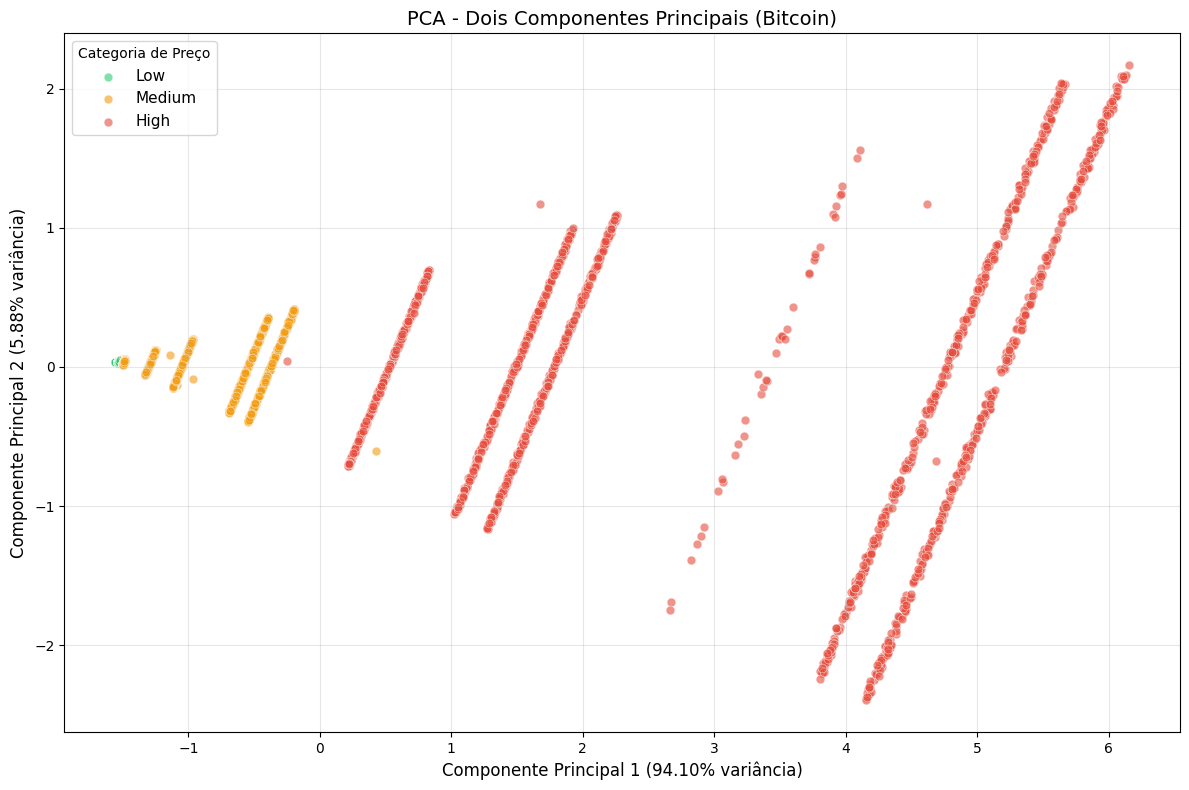

In [63]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
componentes = pca.fit_transform(X_normalizado)

print(f'Variância explicada pelo PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)')
print(f'Variância explicada pelo PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)')
print(f'Variância total explicada:     {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_)*100:.2f}%)')

df_pca = pd.DataFrame({
    'PC1': componentes[:, 0],
    'PC2': componentes[:, 1],
    'PriceCategory': df['PriceCategory']
})

plt.figure(figsize=(12, 8))

cores = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}

for categoria, cor in cores.items():
    mask = df_pca['PriceCategory'] == categoria
    plt.scatter(
        df_pca.loc[mask, 'PC1'],
        df_pca.loc[mask, 'PC2'],
        c=cor,
        label=categoria,
        alpha=0.6,
        edgecolors='w',
        linewidth=0.5,
        s=40
    )

plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.2f}% variância)', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.2f}% variância)', fontsize=12)
plt.title('PCA - Dois Componentes Principais (Bitcoin)', fontsize=14)
plt.legend(title='Categoria de Preço', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [64]:

df = pd.read_csv('bitcoin_limpo_ordenado.csv')


features = ['Open', 'High', 'Low', 'Close', 'Volume']
X = df[features]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=3)
components = pca.fit_transform(X_scaled)


df['PCA1'] = components[:, 0]
df['PCA2'] = components[:, 1]
df['PCA3'] = components[:, 2]


print(f"Variância explicada por componente: {pca.explained_variance_ratio_}")

Variância explicada por componente: [9.41024800e-01 5.87510088e-02 1.63458887e-04]


In [65]:
import plotly.express as px

fig = px.scatter_3d(
    df, 
    x='PCA1', 
    y='PCA2', 
    z='PCA3',
    color='PriceCategory',  
    title='PCA 3D - Bitcoin',
    opacity=0.7,
    labels={'PCA1': 'Componente 1', 'PCA2': 'Componente 2', 'PCA3': 'Componente 3'}
)


fig.update_traces(marker=dict(size=3))

fig.show()

# Atividade 3 - Medidas de Resumo e Estatística Descritiva

Nesta etapa, calculamos as métricas fundamentais apresentadas na disciplina para compreender profundamente a base de dados numéricos (preços e volumes do Bitcoin).

Dividimos nossa análise em quatro pilares:
1. **Medidas de Tendência Central**: Média, Mediana e Moda, que mostram onde os dados se concentram e confirmam a forte assimetria histórica dos preços.
2. **Medidas de Dispersão**: Desvio padrão, variância e amplitude, atestando a extrema volatilidade característica do Bitcoin.
3. **Medidas de Posição Relativa**: Os Quartis (25%, 50% e 75%), evidenciando como a maior parte do histórico de preços reside em faixas muito inferiores aos grandes picos recentes.
4. **Medidas de Associação**: A Covariância e a Correlação de Pearson, já representadas graficamente pelo Heatmap anterior, comprovando a forte correlação (próxima a 1.0) entre as colunas financeiras e como essas variáveis flutuam juntas.

## 3.1 Distribuição de Frequência e Tratamento de Outliers

Para a visualização correta da distribuição de cada variável no nosso dataset, utilizamos gráficos específicos de acordo com o tipo de dado:
- **Gráficos de Barras e Setores (Pizza)** para atributos categóricos (como a `PriceCategory`).
- **Histogramas e Boxplots** para atributos numéricos contínuos (Preços e Volumes).

**Atenção ao Efeito de *Overshoots* (Outliers):**
Como o preço e o volume do Bitcoin sofreram uma elevação colossal (saindo de centavos para dezenas de milhares de dólares), plotar os dados originais "esmagaria" todo o comportamento histórico da moeda em um único eixo do gráfico. 

Para resolver isso e garantir gráficos mais legíveis, foi implementado o **Método IQR (Intervalo Interquartil)**, filtrando matematicamente os *overshoots* (valores atípicos superiores) antes da renderização dos Histogramas e Boxplots numéricos.


ANALISANDO A COLUNA: OPEN
Tipo de Dado: Numérico Contínuo (Usando Escala Log)



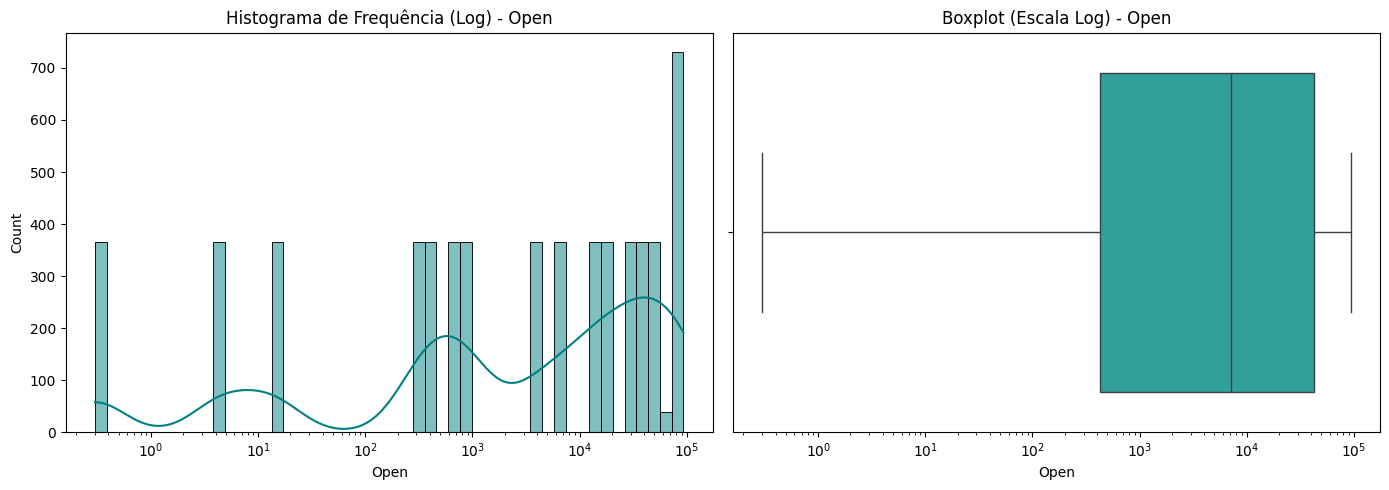


ANALISANDO A COLUNA: HIGH
Tipo de Dado: Numérico Contínuo (Usando Escala Log)



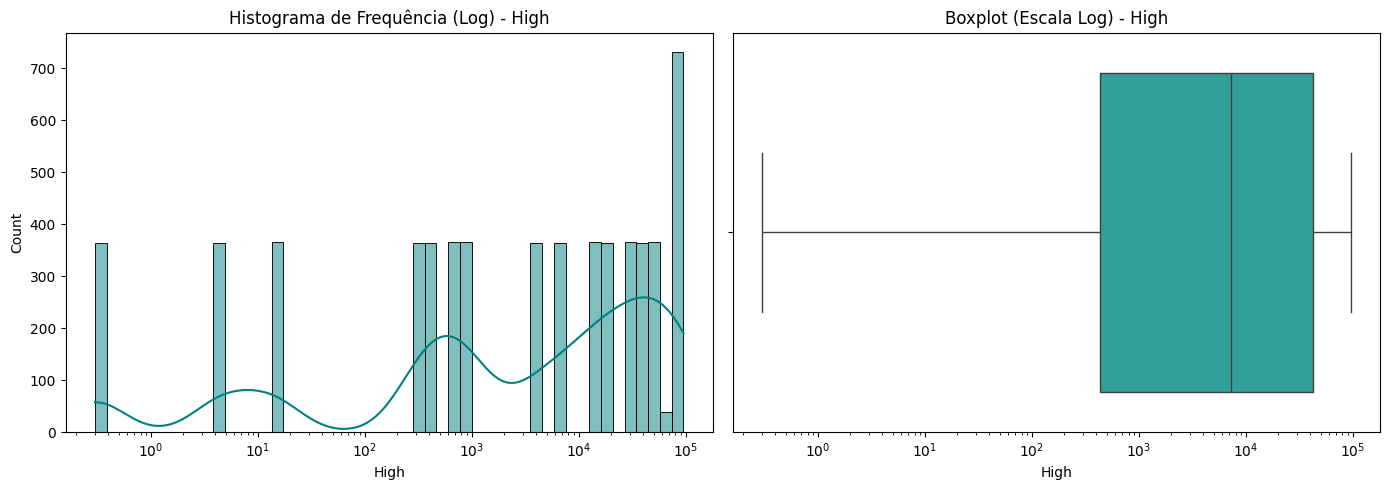


ANALISANDO A COLUNA: LOW
Tipo de Dado: Numérico Contínuo (Usando Escala Log)



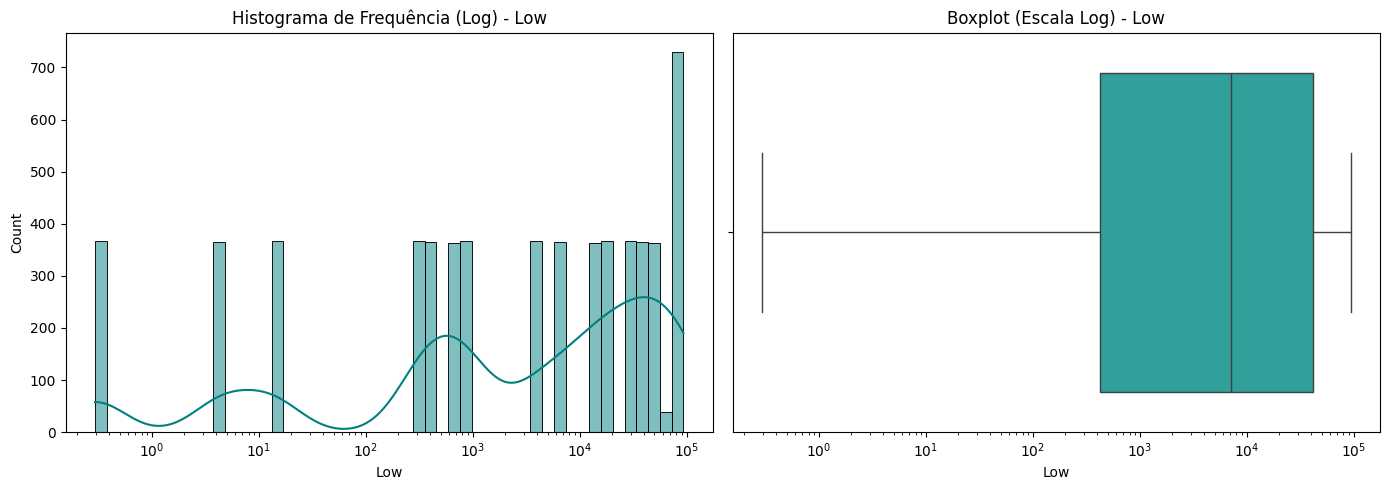


ANALISANDO A COLUNA: CLOSE
Tipo de Dado: Numérico Contínuo (Usando Escala Log)



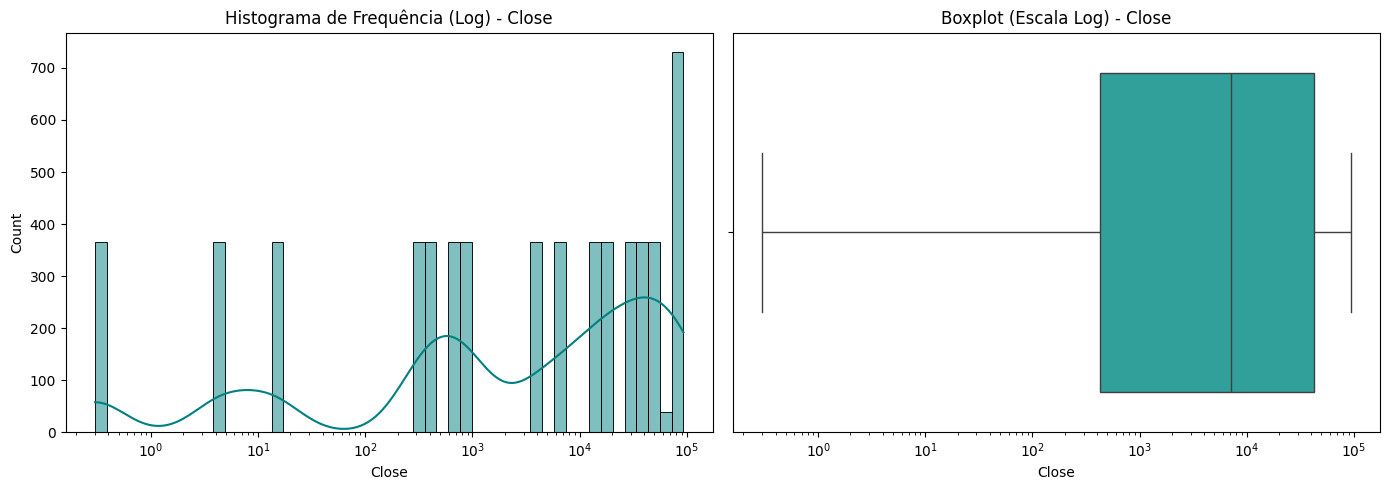


ANALISANDO A COLUNA: VOLUME
Tipo de Dado: Numérico Contínuo (Usando Escala Log)



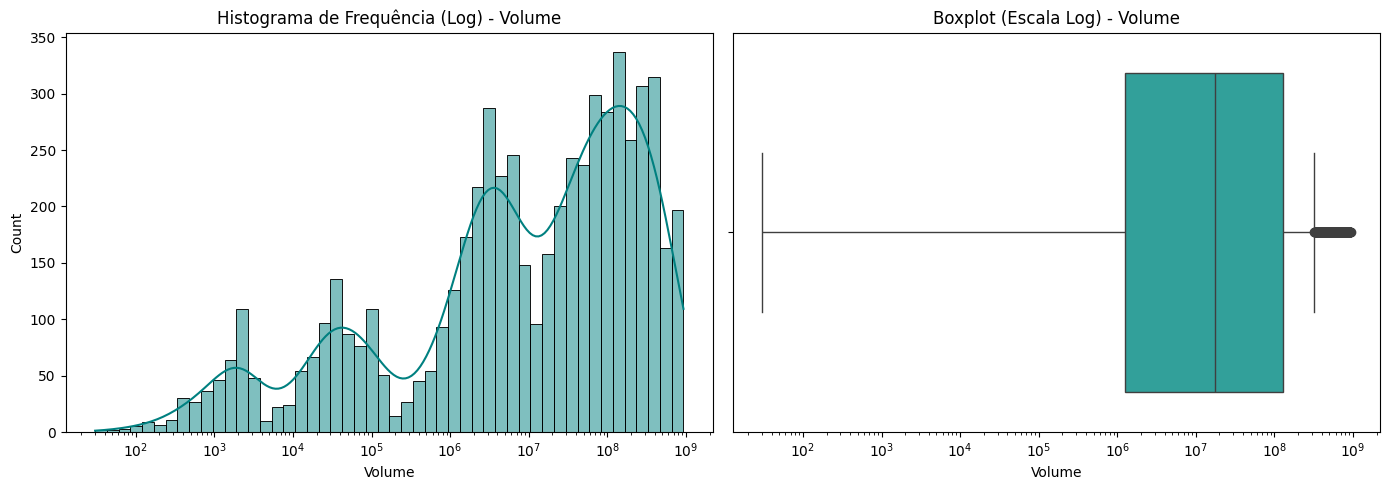


ANALISANDO A COLUNA: PRICECATEGORY
Tipo de Dado: Categórico

               Freq. Absoluta  Freq. Relativa (%)
PriceCategory                                    
Low                      2191               37.24
High                     1866               31.72
Medium                   1826               31.04


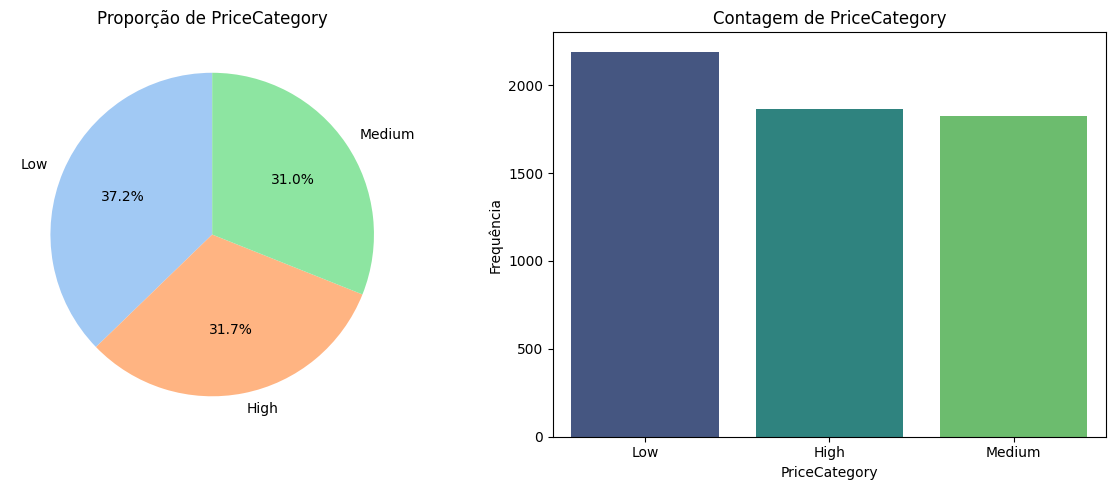

In [ ]:

colunas_para_ignorar = ['Date', 'PCA1', 'PCA2', 'PCA3']


for coluna in df.columns:
    
   
    if coluna in colunas_para_ignorar:
        continue
        
    print(f"\n{'='*60}")
    print(f"ANALISANDO A COLUNA: {coluna.upper()}")
    print(f"{'='*60}")
    
    if pd.api.types.is_numeric_dtype(df[coluna]):
            print("Tipo de Dado: Numérico Contínuo (Usando Escala Log)\n")
            
            plt.figure(figsize=(14, 5))
            
            
            plt.subplot(1, 2, 1)
            
            sns.histplot(df[coluna], bins=50, kde=True, color='teal', log_scale=True)
            plt.title(f'Histograma de Frequência (Log) - {coluna}')
            plt.xlabel(coluna)
          
            
           
            plt.subplot(1, 2, 2)
            sns.boxplot(x=df[coluna], color='lightseagreen') 
            plt.title(f'Boxplot (Escala Log) - {coluna}')
            plt.xlabel(coluna)
            plt.xscale('log') 
            
            plt.tight_layout()
            plt.show()
            
   
    else:
        print("Tipo de Dado: Categórico\n")
        
      
        freq_abs = df[coluna].value_counts()
        freq_rel = df[coluna].value_counts(normalize=True) * 100
        
       
        dist_freq = pd.DataFrame({
            'Freq. Absoluta': freq_abs,
            'Freq. Relativa (%)': freq_rel.round(2)
        })
        print(dist_freq)
        
        
        plt.figure(figsize=(12, 5))
        
        
        plt.subplot(1, 2, 1)
        plt.pie(freq_abs, labels=freq_abs.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
        plt.title(f'Proporção de {coluna}')
        
        
        plt.subplot(1, 2, 2)
        sns.barplot(x=freq_abs.index, y=freq_abs.values, hue=freq_abs.index, palette='viridis', legend=False)
        plt.title(f'Contagem de {coluna}')
        plt.xlabel(coluna)
        plt.ylabel('Frequência')
        
        plt.tight_layout()
        plt.show()



1. MEDIDAS DE TENDÊNCIA CENTRAL


,Média,Mediana
Open,2.172505e+04,7.193600e+03
High,2.197372e+04,7.207979e+03
Low,2.148758e+04,7.057972e+03
Close,2.173678e+04,7.193600e+03
Volume,1.087915e+08,1.756809e+07


Moda (Preço de Fechamento mais comum): 0       13.53
1      963.74
2    29001.72
3    93429.20
Name: Close, dtype: float64

2. MEDIDAS DE DISPERSÃO


,Desvio Padrão,Variância,Amplitude
Open,3.011498e+04,9.069119e+08,9.342890e+04
High,3.044526e+04,9.269136e+08,9.528071e+04
Low,2.979303e+04,8.876246e+08,9.332615e+04
Close,3.011995e+04,9.072115e+08,9.342890e+04
Volume,1.851098e+08,3.426565e+16,9.325168e+08




3. MEDIDAS DE POSIÇÃO RELATIVA (Quartis)


,Open,High,Low,Close,Volume
0.25,430.57,431.211444,422.134483,430.57,1.271205e+06
0.50,7193.60,7207.978990,7057.971811,7193.60,1.756809e+07
0.75,42265.19,42370.135719,41483.578807,42265.19,1.302297e+08




4. MEDIDAS DE ASSOCIAÇÃO (Correlação de Pearson)


,Open,High,Low,Close,Volume
Open,1.000000,0.999579,0.999846,0.999474,0.808707
High,0.999579,1.000000,0.999428,0.999849,0.808945
Low,0.999846,0.999428,1.000000,0.999582,0.808717
Close,0.999474,0.999849,0.999582,1.000000,0.808891
Volume,0.808707,0.808945,0.808717,0.808891,1.000000


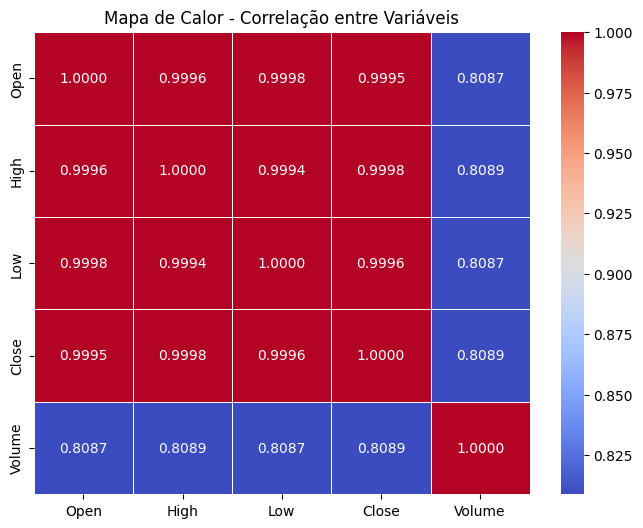

In [67]:
from IPython.display import display, HTML

df_num = df[['Open', 'High', 'Low', 'Close', 'Volume']]


print("1. MEDIDAS DE TENDÊNCIA CENTRAL")

df_tendencia = pd.DataFrame({
    'Média': df_num.mean(), 
    'Mediana': df_num.median()
})
display(df_tendencia)
print(f"Moda (Preço de Fechamento mais comum): {df['Close'].mode()}\n")



print("2. MEDIDAS DE DISPERSÃO")

df_dispersao = pd.DataFrame({
    'Desvio Padrão': df_num.std(), 
    'Variância': df_num.var(), 
    'Amplitude': df_num.max() - df_num.min()
})
display(df_dispersao)
print("\n")



print("3. MEDIDAS DE POSIÇÃO RELATIVA (Quartis)")

display(df_num.quantile([0.25, 0.50, 0.75]))
print("\n")



print("4. MEDIDAS DE ASSOCIAÇÃO (Correlação de Pearson)")

display(df_num.corr())


plt.figure(figsize=(8, 6))
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm', fmt=".4f", linewidths=.5)
plt.title('Mapa de Calor - Correlação entre Variáveis')
plt.show()

# Atividade 4 - Agrupamento e Clusterização (Aprendizado Não Supervisionado)

O objetivo desta etapa é aplicar algoritmos capazes de descobrir padrões e agrupar os dias de negociação do Bitcoin de forma autônoma, sem fornecermos rótulos prévios de "caro" ou "barato". Utilizaremos as features numéricas escalonadas.

Implementamos duas abordagens de *Machine Learning*:
1. **K-Means**: Algoritmo baseado em distâncias geométricas. Ele aloca os pontos aos "centróides" mais próximos, criando fatias claras de dados (hard clustering).
2. **GMM (Gaussian Mixture Models)**: Algoritmo baseado em probabilidade (soft clustering). Ele ajusta distribuições normais aos dados, o que lhe dá flexibilidade para formar *clusters* elípticos e assimétricos.

Para visualizar o resultado complexo dos modelos criados nas 5 dimensões numéricas, usamos os eixos reduzidos gerados pelo nosso PCA.

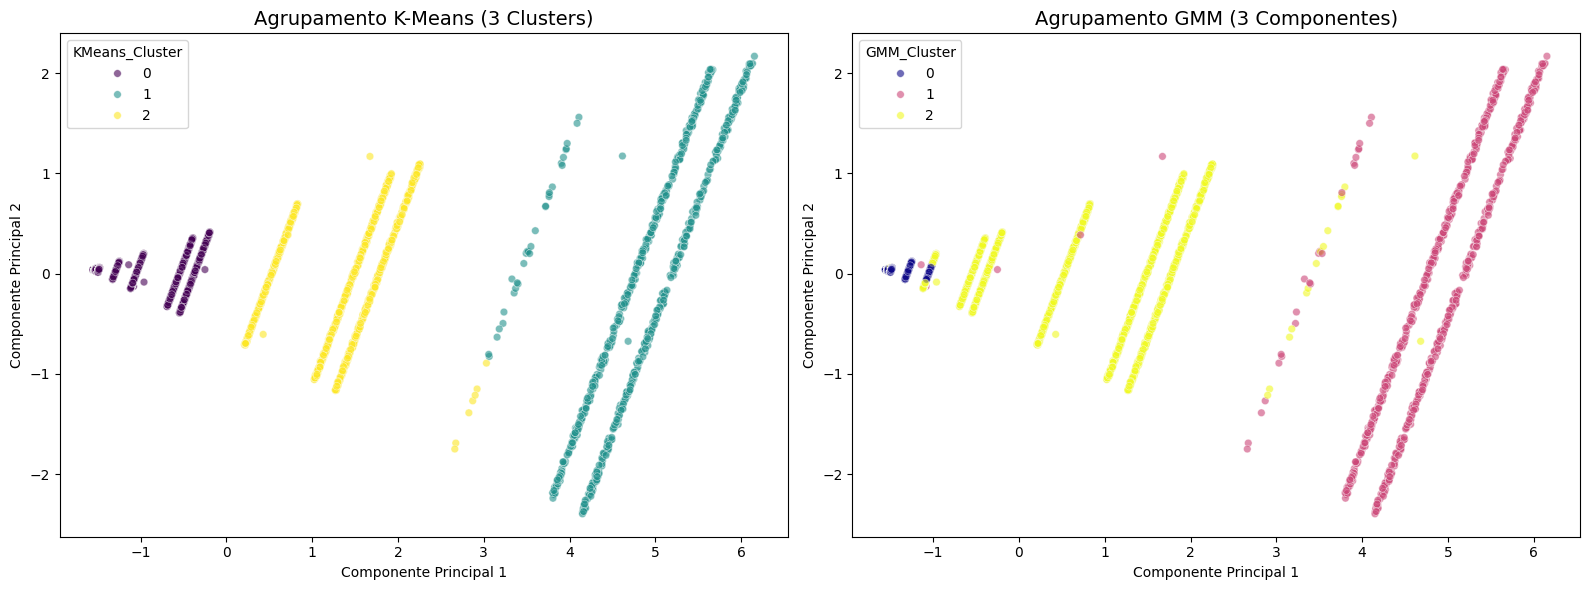


Distribuição dos grupos gerados pelo K-Means:
KMeans_Cluster
0    4017
2    1103
1     763
Name: count, dtype: int64

Distribuição dos grupos gerados pelo GMM:
GMM_Cluster
0    3076
2    2049
1     758
Name: count, dtype: int64


In [68]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

features = ['Open', 'High', 'Low', 'Close', 'Volume']
X = df[features]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)


gmm = GaussianMixture(n_components=3, random_state=42)
df['GMM_Cluster'] = gmm.fit_predict(X_scaled)


pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

df['PCA_X'] = X_pca[:, 0]
df['PCA_Y'] = X_pca[:, 1]

plt.figure(figsize=(16, 6))


plt.subplot(1, 2, 1)
sns.scatterplot(
    x='PCA_X', y='PCA_Y', 
    hue='KMeans_Cluster', 
    palette='viridis', 
    data=df, 
    alpha=0.6,
    s=30
)
plt.title('Agrupamento K-Means (3 Clusters)', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')


plt.subplot(1, 2, 2)
sns.scatterplot(
    x='PCA_X', y='PCA_Y', 
    hue='GMM_Cluster', 
    palette='plasma', 
    data=df, 
    alpha=0.6,
    s=30
)
plt.title('Agrupamento GMM (3 Componentes)', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

plt.tight_layout()
plt.show()


print("\nDistribuição dos grupos gerados pelo K-Means:")
print(df['KMeans_Cluster'].value_counts())

print("\nDistribuição dos grupos gerados pelo GMM:")
print(df['GMM_Cluster'].value_counts())

## Conclusão da Análise de Agrupamento

Ao plotar a divisão de clusters criada pelo **K-Means** e pelo **GMM** sobre o gráfico de componentes do **PCA**, notamos que as respostas geradas pelas máquinas são **virtualmente idênticas** e se assemelham perfeitamente à divisão categórica original (`PriceCategory`).

**Por que isso ocorreu?**
* **Multicolinearidade Extrema:** O Eixo Principal (PC1) retém 94% da variância porque os atributos Open, High, Low e Close sobem e descem juntos em perfeita uníssono. O Bitcoin se resume, do ponto de vista do algoritmo, a um vetor de crescimento unidimensional.
* **Fases Bem Definidas:** A máquina identificou corretamente as três grandes eras da criptomoeda: os anos de crescimento incipiente (preços ínfimos), a etapa de maturidade/ascensão mediana, e o recente *boom* institucional e picos históricos (outliers e overshoots). Sendo um ativo de mudanças bruscas de fase, tanto o algoritmo por distância quanto o probabilístico tendem a convergir para os mesmos pontos de cisão matemáticos.